In [31]:
import pandas as pd

In [32]:
from google.colab import files
uploaded = files.upload() #I use google colab because my laptop is weak so i used this cell to upload the file

Saving sicence.csv.csv to sicence.csv (2).csv


In [33]:
khaled = pd.read_csv("sicence.csv.csv") #read the file
khaled.info()
khaled.tail() #info and tail to check my file uploaded

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


,TV,Sales
195,38.2,7.6
196,94.2,9.7
197,177.0,12.8
198,283.6,25.5
199,232.1,13.4


In [34]:
khaled.head() #to complette check

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


<Axes: xlabel='TV', ylabel='Sales'>

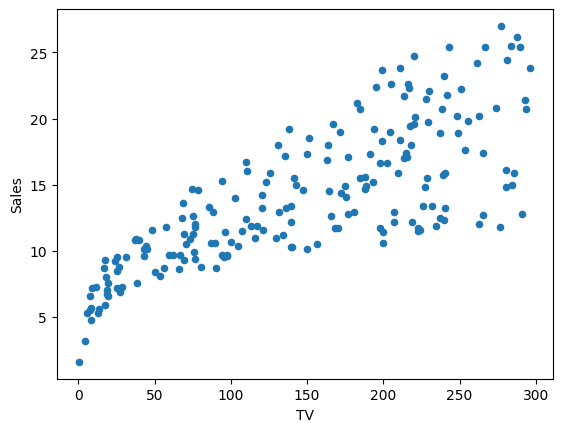

In [35]:
#Visualise the relationship between the features and the response using scatterplots
khaled.plot(x='TV',y='Sales',kind='scatter')

In [36]:
X = khaled["TV"]
Y = khaled["Sales"]

In [37]:
X = X.values.reshape(-1,1)

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8 , random_state=2) # use random state to make the output do not change


In [39]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape) #to check the data

(160, 1)
(160,)
(40, 1)
(40,)


In [40]:
# import LinearRegression from sklearn
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
print(lr.intercept_)    #seta(0)
print(lr.coef_)     #seta(1)

6.566524608650465
[0.05245828]


In [42]:
#then the hypothesis function is set0+set1*X = 6.566524608650465+0.05245828*X
#so Sales = 6.566524608650465+0.05245828*TV

In [43]:
# Making predictions on the testing set
Y_pred = lr.predict(X_test)

In [48]:
Y_pred[:5] #to check results

array([15.78344456, 10.27007924,  9.51467999, 18.7420916 , 15.31656586])

In [47]:
Y_test[:5]

,Sales
112,14.1
29,10.5
182,8.7
199,13.4
193,19.6


In [45]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

mse = mean_squared_error(Y_test, Y_pred)
rmse = root_mean_squared_error(Y_test, Y_pred)
r_squared = r2_score(Y_test, Y_pred)

print('Mean_Squared_Error :' ,mse)
print('Root_Mean_Squared_Error :' ,rmse)
print('r_square_value :',r_squared)

Mean_Squared_Error : 17.792893505799903
Root_Mean_Squared_Error : 4.218162337535138
r_square_value : 0.04217977642788051
